### Importação de Bibliotecas

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Abstração do Perceptron

In [ ]:
class Perceptron():
    w = [] # Pesos
    b = 0 # Viés

    def __init__(self, description = ""):
        self.description = description

    def __repr__(self) -> str:
        return f"Perceptron({self.description})"

    def hardlim(self, x) -> int:
        return 1 if x >= 0 else 0

    def eval_error(self, error ) -> int:
        return np.absolute( error ).sum()

    def train( self, matrix_in, vector_out, epoch_max = 10):
        # Supervisão
        self.X = matrix_in = np.array(matrix_in)
        self.Y = vector_out = np.array(vector_out)

        # Inicia Aleatoriamente
        error = np.ones( vector_out.size )
        self.w = np.random.rand( matrix_in.shape[-1], 1)
        self.b = np.random.rand()
        self.epoch = 0

        # Iteração
        while self.eval_error( error ):
            for index, patter in enumerate( matrix_in ):
                calc_out = self.hardlim( patter@self.w + self.b )
                error[index] = vector_out[index] - calc_out
                self.w = self.w + error[index]*patter.reshape( len(patter) ,1)
                self.b = self.b + error[index]
            self.epoch += 1


            if self.epoch == epoch_max:
                print("Insufficient dimensionss")
                return self.epoch

        print("Solution found. Epoch", self.epoch)
        return self.epoch

    def test(self, input: list):
        input = np.array(input)
        return self.hardlim( input@self.w + self.b )


    def graph( self ):
        if ( self.epoch > 0 ):
            plt.scatter( self.X[self.Y == 0,0] , self.X[self.Y == 0,1], c="blue")
            plt.scatter( self.X[self.Y == 1,0] , self.X[self.Y == 1,1], c="salmon")
            p1 = np.linspace( self.X.min() - 1, self.X.max() + 1, 10 )
            p2 = -(self.w[0]/self.w[1])*p1 -self.b/self.w[1];
            plt.plot(p1,p2)
            plt.axis('equal')
            plt.xlim([self.X.min() - 1, self.X.max() + 1])
            plt.ylim([self.X.min() - 1, self.X.max() + 1])
            plt.grid()
            plt.show()


# Código + Explicação



*   Usamos MLP pois é capaz de separar de forma não linear.
*   Usamos 1 camada oculta com 4 neurônios. O mínimo são 2, mas 4 garante mais velocidade e precisão.



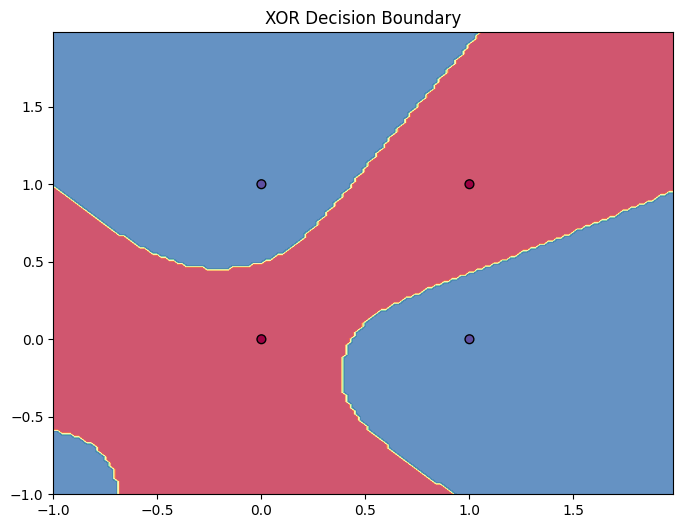

In [ ]:
# Dados de entrada para o XOR
inputs = [[0,0], [0,1], [1,0], [1,1]]
outputs = [0, 1, 1, 0]

# Treinando o modelo e gerando o gráfico de separação
mlp = MLP(hidden_size=4)
mlp.train(inputs, outputs, epochs=10000, lr=0.1)

# Visualizando a fronteira de decisão
plt.figure(figsize=(8, 6))
mlp.plot_boundary(inputs, outputs)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class MLP():
    def __init__(self, input_size=2, hidden_size=4, output_size=1):
        self.W1 = np.random.randn(input_size, hidden_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size)
        self.b2 = np.zeros((1, output_size))

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

    def train(self, X, y, epochs=10000, lr=0.1):
        X = np.array(X)
        y = np.array(y).reshape(-1, 1)
        for epoch in range(epochs):
            output = self.forward(X)
            error = y - output
            d_output = error * self.sigmoid_derivative(output)
            error_hidden = d_output.dot(self.W2.T)
            d_hidden = error_hidden * self.sigmoid_derivative(self.a1)
            self.W2 += self.a1.T.dot(d_output) * lr
            self.b2 += np.sum(d_output, axis=0, keepdims=True) * lr
            self.W1 += X.T.dot(d_hidden) * lr
            self.b1 += np.sum(d_hidden, axis=0, keepdims=True) * lr

    def predict(self, X):
        return (self.forward(X) > 0.5).astype(int)

    def plot_boundary(self, X, y):
        X = np.array(X)
        y = np.array(y)
        h = .02
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
        Z = self.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
        plt.scatter(X[:, 0], X[:, 1], c=y, s=40, edgecolors='k', cmap=plt.cm.Spectral)
        plt.title("XOR Decision Boundary")
        plt.show()

Insufficient dimensionss


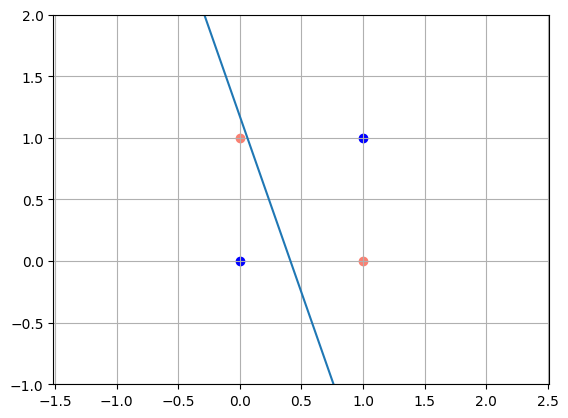

In [ ]:
# XOR gate
inputs = [[0,0],[0,1],[1,0],[1,1]]
outputs = [0,1,1,0]
neuron.train(inputs, outputs)
neuron.graph()